# Zrozumienie mechanizmu działania Transformerów w LLM

**Instrukcja wykonania krok po kroku**

Ćwiczenie realizujecie w przygotowanym notebooku z załączenia do postu.

## Krok 1: Tokenizacja

- **Zadanie**: Uruchomcie komórki w sekcji 1. Zmieńcie zdanie wejściowe na własny przykład (np. zdanie z polskimi znakami lub specjalistyczną terminologią).
- **Cel**: Zrozumienie, jak tekst jest konwertowany na ID tokenów i dlaczego niektóre słowa są dzielone na części.

## Krok 2: Mechanizm Self-Attention

- **Zadanie**: Wykonajcie sekcje 2 i 3. Wypełnijcie macierz wag w zadaniu 2C i wykonajcie ręczne obliczenia w sekcji 3.
- **Cel**: Zrozumienie roli macierzy Q, K i V oraz funkcji Softmax w obliczaniu ważności kontekstu dla każdego tokena.

## Krok 3: Generowanie i Causal Mask

- **Zadanie**: Przeanalizujcie sekcję 4 dotyczącą maskowania (Causal Mask). Uruchomcie generowanie tekstu przy użyciu modelu `distilgpt2` i eksperymentujcie z parametrem `temperature`.
- **Cel**: Zrozumienie, jak model przewiduje kolejny token i jak "temperatura" wpływa na rozkład prawdopodobieństwa (kreatywność vs przewidywalność).

# Ćwiczenie: Jak działają transformery w modelach LLM
 
**Cel:** zrozumienie tokenizacji, self-attention, maskowania oraz generowania token po tokenie w modelach transformerowych.

## Efekty uczenia
Po wykonaniu ćwiczenia student potrafi:
- wyjaśnić rolę tokenizacji i embeddingów,
- opisać intuicję działania self-attention,
- odróżnić attention pełny od attention maskowanego (causal),
- uruchomić prosty eksperyment z modelem transformers,
- zinterpretować wpływ parametrów generowania na wynik modelu.


## Instrukcja pracy
1. Wykonuj komórki **po kolei**.
2. Nie przechodź dalej, dopóki nie uzupełnisz odpowiedzi tekstowych.
3. Tam, gdzie widzisz `TODO`, wpisz własną odpowiedź.
4. Po każdej części zapisz krótki wniosek.
5. Na końcu zapisz notebook z uzupełnionymi odpowiedziami i oddaj go prowadzącemu.


In [37]:
# Jeśli pracujesz w Google Colab, odkomentuj poniższą linię przy pierwszym uruchomieniu:
# !pip -q install transformers torch pandas matplotlib seaborn

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
import torch

sns.set_theme(style='whitegrid')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device


'cpu'

## Część 1. Tokenizacja i wejście do modelu (20 min)
Transformer nie operuje bezpośrednio na zdaniach, lecz na **tokenach**. W tej części sprawdzisz, jak tokenizer dzieli tekst na jednostki wejściowe.

### Zadanie 1A
Przed uruchomieniem kodu odpowiedz własnymi słowami:
- Czym różni się znak od słowa i od tokena?
- Dlaczego model nie pracuje na pełnych zdaniach jako pojedynczych obiektach?

**Twoja odpowiedź:**

Dla mnie znak odpowiada char w C, słowo to kilka znaków mających znaczenie w piśmie/wymowie, a token to wydzielona część zdania (słowo, liczba, '.', ',') mająca pewną wagę (id).
Modele nie pracują na zdaniach jako obiektach, ponieważ jest to nieefektywne (model musiałby generować zdanie po zdaniu, zamiast słowo po słowie), tym samym nie wiedziałby jak się zachować przy niepełnych zdaniach lub przy fragmencie kodu.


In [38]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
text = 'Transformers are changing natural language processing.'
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
pd.DataFrame({'token': tokens, 'token_id': token_ids})

,token,token_id
0,transformers,19081
1,are,2024
2,changing,5278
3,natural,3019
4,language,2653
5,processing,6364
6,.,1012


In [39]:
text = 'CachyOS wymaga aktualizacji pakietów, w celu zwiększenia wydajności, bezpieczeństwa oraz aktualizacji sterowników.'
#text = 'CachyOS requires package updates for performance, security, and driver updates.'
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
pd.DataFrame({'token': tokens, 'token_id': token_ids})

,token,token_id
0,ca,6187
1,##chy,11714
2,##os,2891
3,w,1059
4,##ym,24335
5,##aga,16098
6,ak,17712
7,##tua,26302
8,##li,3669
9,##za,4143


In [40]:
text = 'Dziennie aktualizuję kompa, żeby mi nie mulił.'
#text = "I update my computer daily so it doesn't slow me down."
tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)
pd.DataFrame({'token': tokens, 'token_id': token_ids})

,token,token_id
0,d,1040
1,##zie,14272
2,##nni,23500
3,##e,2063
4,ak,17712
5,##tua,26302
6,##li,3669
7,##zu,9759
8,##je,6460
9,ko,12849


### Zadanie 1B
1. Zmień wartość zmiennej `text` na własne zdanie techniczne lub potoczne.
2. Uruchom komórkę ponownie.
3. Sprawdź, czy któreś słowo zostało rozbite na kilka tokenów.

**Odpowiedz:**
- Które fragmenty zostały rozbite?
- Co to mówi o sposobie reprezentacji języka przez model?

**Twoja odpowiedź:**

Aktualny model, w polskich zdaniach rozbija każde słowo na sylaby (lub mniej), w porównaniu z odpowiednikiem zdania po angielsku. Dzieje się tak, ponieważ polskie słowa mają wiele form (biegam, biegniesz, pobiegnę (...) vs run, running (..)), gdyby model miał dzielić na słowa polskie musiałby mieć ogromny słownik.


## Część 2. Intuicja self-attention na małym przykładzie
W self-attention każdy token porównuje się z innymi tokenami w sekwencji. Dzięki temu model może ocenić, które słowa są ważne przy interpretacji danego słowa.

### Zadanie 2A
Przeczytaj zdanie: **"The animal didn't cross the street because it was too tired."**

Zanim uruchomisz kod, odpowiedz:
- Do czego odnosi się słowo `it`?
- Które wcześniejsze słowa powinny mieć wysoką wagę uwagi przy interpretacji `it`?

**Twoja odpowiedź:**

`It` odnosi się do `animal`.
Wcześniejsze słowa wysokiej wagi to: `animal`, `street`.


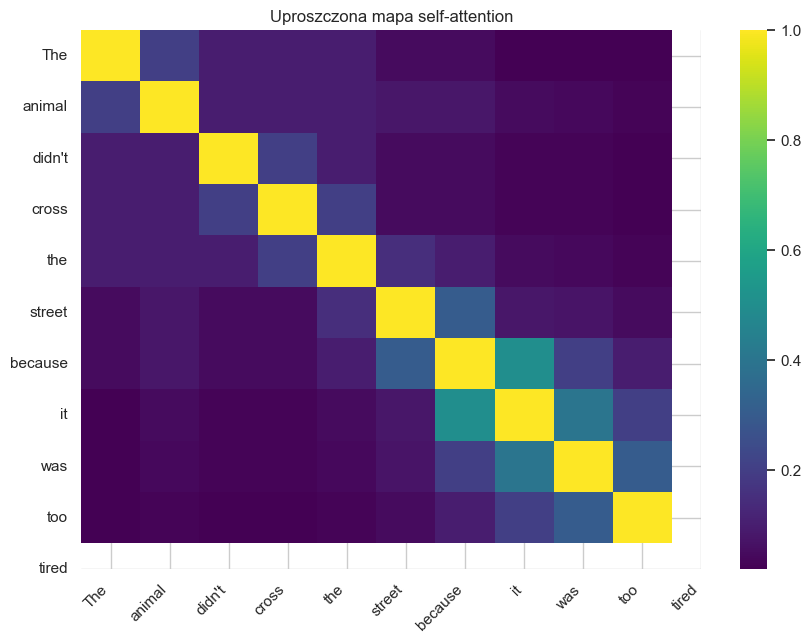

In [41]:
sentence = "The animal didn't cross the street because it was too tired."
words = sentence.replace('.', '').split()

attention_scores = np.array([
    [1.0, 0.2, 0.1, 0.1, 0.1, 0.05, 0.05, 0.02, 0.02, 0.02],
    [0.2, 1.0, 0.1, 0.1, 0.1, 0.08, 0.08, 0.05, 0.04, 0.03],
    [0.1, 0.1, 1.0, 0.2, 0.1, 0.05, 0.05, 0.03, 0.03, 0.02],
    [0.1, 0.1, 0.2, 1.0, 0.2, 0.05, 0.05, 0.03, 0.03, 0.02],
    [0.1, 0.1, 0.1, 0.2, 1.0, 0.15, 0.1, 0.05, 0.04, 0.03],
    [0.05, 0.08, 0.05, 0.05, 0.15, 1.0, 0.3, 0.08, 0.07, 0.05],
    [0.05, 0.08, 0.05, 0.05, 0.1, 0.3, 1.0, 0.5, 0.2, 0.1],
    [0.02, 0.05, 0.03, 0.03, 0.05, 0.08, 0.5, 1.0, 0.4, 0.2],
    [0.02, 0.04, 0.03, 0.03, 0.04, 0.07, 0.2, 0.4, 1.0, 0.3],
    [0.02, 0.03, 0.02, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 1.0],
])

plt.figure(figsize=(10, 7))
sns.heatmap(attention_scores, xticklabels=words, yticklabels=words, cmap='viridis')
plt.title('Uproszczona mapa self-attention')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


### Zadanie 2B
1. Odszukaj wiersz i kolumnę odpowiadającą tokenowi `it`.
2. Wskaż 2–3 tokeny, na które `it` zwraca największą uwagę.
3. Napisz, czy wynik zgadza się z Twoją intuicją.

**Twoja odpowiedź:**
`It` odpowiada wierszowi: 8, kolumnie: 8 (pod koniec macierzy).

Według wykresu `it` zwraca szczególną uwagę na `bacause`, `was` oraz na siebie.

Wynik jest inny niż się spodziewałem.


### Zadanie 2C
Zmodyfikuj zdanie na własny przykład z niejednoznacznym zaimkiem, np.:
- "The trophy didn't fit in the suitcase because it was too big."
- "The server restarted after it exceeded memory limits."

Następnie opisz, które tokeny **powinny** mieć wysoką wagę attention.

**Twoja odpowiedź:**

Przy poniższym zdaniu `it` ma obok siebie uwagę na `after` i `exceeded`, co nie wydaje mi się poprawnie (attention_scores są takie same do każdego zdania)

Moim zdanie najwyższą wagę powinno mieć `server`.


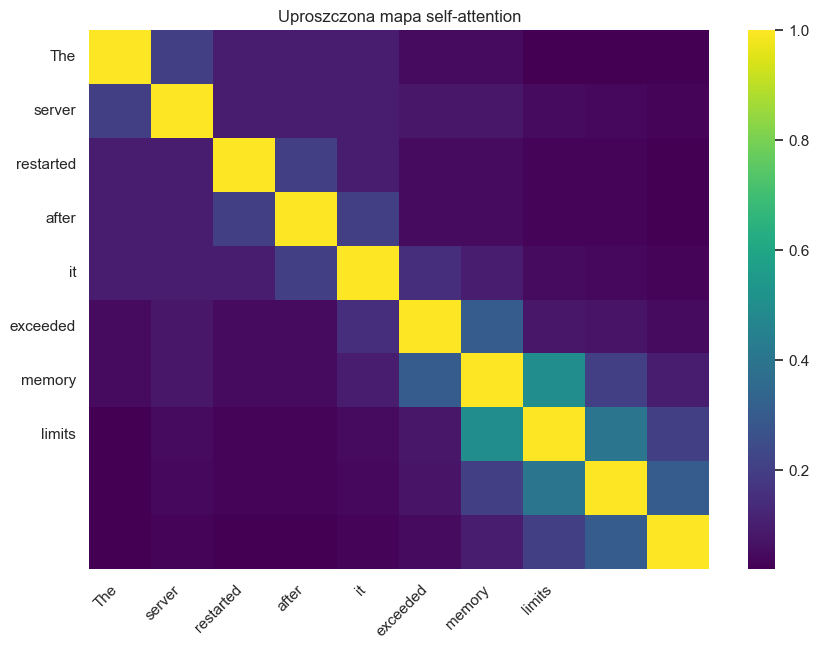

In [42]:
sentence = "The server restarted after it exceeded memory limits."
words = sentence.replace('.', '').split()

attention_scores = np.array([
    [1.0, 0.2, 0.1, 0.1, 0.1, 0.05, 0.05, 0.02, 0.02, 0.02],
    [0.2, 1.0, 0.1, 0.1, 0.1, 0.08, 0.08, 0.05, 0.04, 0.03],
    [0.1, 0.1, 1.0, 0.2, 0.1, 0.05, 0.05, 0.03, 0.03, 0.02],
    [0.1, 0.1, 0.2, 1.0, 0.2, 0.05, 0.05, 0.03, 0.03, 0.02],
    [0.1, 0.1, 0.1, 0.2, 1.0, 0.15, 0.1, 0.05, 0.04, 0.03],
    [0.05, 0.08, 0.05, 0.05, 0.15, 1.0, 0.3, 0.08, 0.07, 0.05],
    [0.05, 0.08, 0.05, 0.05, 0.1, 0.3, 1.0, 0.5, 0.2, 0.1],
    [0.02, 0.05, 0.03, 0.03, 0.05, 0.08, 0.5, 1.0, 0.4, 0.2],
    [0.02, 0.04, 0.03, 0.03, 0.04, 0.07, 0.2, 0.4, 1.0, 0.3],
    [0.02, 0.03, 0.02, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 1.0],
])

plt.figure(figsize=(10, 7))
sns.heatmap(attention_scores, xticklabels=words, yticklabels=words, cmap='viridis')
plt.title('Uproszczona mapa self-attention')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


## Część 3. Uproszczone attention krok po kroku
Teraz policzysz bardzo uproszczoną wersję attention. Nie używamy pełnego modelu, tylko mały przykład numeryczny, aby zobaczyć mechanikę obliczeń.


In [48]:
tokens = ['Ala', 'lubi', 'kawę']
X = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
    [1.0, 1.0, 0.0]
])

Wq = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])
Wk = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [1.0, 0.0]
])
Wv = np.array([
    [1.0, 0.0],
    [0.5, 1.0],
    [0.0, 1.0]
])

Q = X @ Wq
K = X @ Wk
V = X @ Wv
scores = Q @ K.T / math.sqrt(K.shape[1])

def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scores)
output = weights @ V

print('Q =')
print(Q)
print('\nK =')
print(K)
print('\nV =')
print(V)
print('\nAttention weights =')
print(np.round(weights, 3))
print('\nOutput =')
print(np.round(output, 3))


Q =
[[2. 1.]
 [1. 2.]
 [1. 1.]]

K =
[[2. 1.]
 [1. 1.]
 [1. 2.]]

V =
[[1.  1. ]
 [0.5 2. ]
 [1.5 1. ]]

Attention weights =
[[0.576 0.14  0.284]
 [0.284 0.14  0.576]
 [0.401 0.198 0.401]]

Output =
[[1.072 1.14 ]
 [1.218 1.14 ]
 [1.102 1.198]]


### Zadanie 3A
Na podstawie wyników odpowiedz:
- Co reprezentują macierze `Q`, `K` i `V`?
- Co oznaczają wartości w `Attention weights`?
- Dlaczego stosujemy funkcję `softmax`?

**Twoja odpowiedź:**

Macierz:
- `Q` query, reprezentuje zapytanie
- `K` key, reprezentuje klucz
- `V` value, reprezentuje faktyczną treść

Wartości `Attention weights` opisują, jak każdy token powinien uwzględniać inny (siebie też)

Stosujemy `softmax` aby znormalizować wynik, wyróżnić wartości (duże -> większe, małe -> mniejsze), wiemy które tokeny są istotne dla zapytania.

### Zadanie 3B
Zmień jedną wartość w macierzy `X` lub jednej z macierzy wag `Wq`, `Wk`, `Wv`, a następnie uruchom obliczenia ponownie.

Opisz:
- która zmiana została wykonana,
- jak zmieniły się wagi attention,
- jak wpłynęło to na końcowy output.

**Twoja odpowiedź:**

Zmieniłem swap Wv[2,0] na Wv[2,1]

Wagi `attention weights` nie zminiły się.

Końcowy output ma znacznie różniący się wynik

In [44]:
tokens = ['Ala', 'lubi', 'kawę']
X = np.array([
    [1.0, 0.0, 1.0],
    [0.0, 1.0, 1.0],
    [1.0, 1.0, 0.0]
])

Wq = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0]
])
Wk = np.array([
    [1.0, 1.0],
    [0.0, 1.0],
    [1.0, 0.0]
])
Wv = np.array([
    [1.0, 0.0],
    [0.5, 1.0],
    [1.0, 0.0]
])

Q = X @ Wq
K = X @ Wk
V = X @ Wv
scores = Q @ K.T / math.sqrt(K.shape[1])

def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scores)
output = weights @ V

print('Q =')
print(Q)
print('\nK =')
print(K)
print('\nV =')
print(V)
print('\nAttention weights =')
print(np.round(weights, 3))
print('\nOutput =')
print(np.round(output, 3))

Q =
[[2. 1.]
 [1. 2.]
 [1. 1.]]

K =
[[2. 1.]
 [1. 1.]
 [1. 2.]]

V =
[[2.  0. ]
 [1.5 1. ]
 [1.5 1. ]]

Attention weights =
[[0.576 0.14  0.284]
 [0.284 0.14  0.576]
 [0.401 0.198 0.401]]

Output =
[[1.788 0.424]
 [1.642 0.716]
 [1.701 0.599]]


## Część 4. Attention maskowany i generowanie token po tokenie
Modele generatywne, takie jak GPT, nie mogą patrzeć w przyszłość. Dlatego używają **causal mask**, która blokuje dostęp do kolejnych tokenów podczas przewidywania następnego słowa.


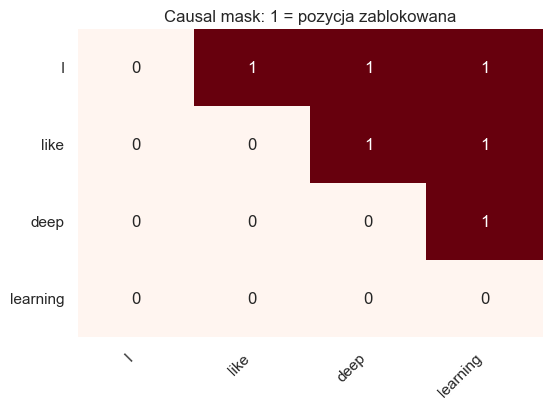

In [45]:
tokens = ['I', 'like', 'deep', 'learning']
n = len(tokens)
mask = np.triu(np.ones((n, n)), k=1)

plt.figure(figsize=(6, 4))
sns.heatmap(mask, annot=True, cbar=False, xticklabels=tokens, yticklabels=tokens, cmap='Reds')
plt.title('Causal mask: 1 = pozycja zablokowana')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()


### Zadanie 4A
Odpowiedz:
- Dlaczego token na pozycji 2 nie powinien widzieć tokenów z pozycji 3 i 4?
- Co by się stało, gdyby model podczas treningu mógł patrzeć na przyszłe tokeny?

**Twoja odpowiedź:**

Token[2] nie widzi token[3..4], ponieważ ma się on nauczyć przewidywania, w przeciwnym przypadku uczyłby się oszukiwać (podglądać przyszłe tokeny)


In [46]:
model_name = 'distilgpt2'
tokenizer_gpt = AutoTokenizer.from_pretrained(model_name)
model_gpt = AutoModelForCausalLM.from_pretrained(model_name).to(device)

prompt = 'Artificial intelligence can'
inputs = tokenizer_gpt(prompt, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model_gpt(**inputs)

logits = outputs.logits[0, -1, :]
top_k = 10
values, indices = torch.topk(logits, top_k)
top_tokens = [tokenizer_gpt.decode([idx]) for idx in indices.tolist()]
top_scores = values.cpu().numpy()

df = pd.DataFrame({'token': top_tokens, 'logit': top_scores})
df


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 10855.71it/s]


,token,logit
0,be,-62.466072
1,help,-63.595890
2,also,-64.344406
3,make,-64.569130
4,create,-64.730682
5,solve,-65.049294
6,predict,-65.116264
7,provide,-65.119148
8,do,-65.351524
9,take,-65.363319


### Zadanie 4B
1. Sprawdź 10 najbardziej prawdopodobnych kolejnych tokenów.
2. Zmień `prompt` na własny początek zdania.
3. Porównaj, jak zmienia się lista tokenów.

**Twoja odpowiedź:**

Lista tokenów zmienia się przewidując kolejne słowo zdania, ich wartości `logit` są podobne.

Dla polskiego zdania oddaje pojedyncze litery.


In [53]:
model_name = 'distilgpt2'
tokenizer_gpt = AutoTokenizer.from_pretrained(model_name)
model_gpt = AutoModelForCausalLM.from_pretrained(model_name).to(device)

#prompt = 'My work is'
prompt = 'Moja praca jest'
inputs = tokenizer_gpt(prompt, return_tensors='pt').to(device)

with torch.no_grad():
    outputs = model_gpt(**inputs)

logits = outputs.logits[0, -1, :]
top_k = 10
values, indices = torch.topk(logits, top_k)
top_tokens = [tokenizer_gpt.decode([idx]) for idx in indices.tolist()]
top_scores = values.cpu().numpy()

df = pd.DataFrame({'token': top_tokens, 'logit': top_scores})
df


Loading weights: 100%|██████████| 76/76 [00:00<00:00, 14269.53it/s]


,token,logit
0,o,-43.920055
1,.,-44.511879
2,\n,-44.568466
3,",",-44.754307
4,j,-45.116623
5,n,-45.162361
6,p,-45.277477
7,i,-45.308125
8,v,-45.385719
9,a,-45.409676


In [54]:
def generate_text(prompt, temperature=1.0, max_new_tokens=30):
    input_ids = tokenizer_gpt(prompt, return_tensors='pt').input_ids.to(device)
    output_ids = model_gpt.generate(
        input_ids,
        do_sample=True,
        temperature=temperature,
        max_new_tokens=max_new_tokens,
        pad_token_id=tokenizer_gpt.eos_token_id
    )
    return tokenizer_gpt.decode(output_ids[0], skip_special_tokens=True)

prompt = 'Large language models are useful because'
for temp in [0.2, 0.7, 1.2]:
    print(f'\nTEMPERATURE = {temp}')
    print(generate_text(prompt, temperature=temp))



TEMPERATURE = 0.2
Large language models are useful because they are used to describe the language in a way that is not possible in a language.













TEMPERATURE = 0.7
Large language models are useful because they can be very useful to developers.























TEMPERATURE = 1.2
Large language models are useful because they demonstrate that you use less text than other languages. Also, while these are used as text, they aren't available to be downloaded for other languages


## Część 5. Wnioski końcowe
Uzupełnij poniższe pytania pełnymi zdaniami.

### Pytania końcowe
1. Jaką rolę pełni tokenizacja w LLM?
2. Na czym polega mechanizm self-attention?
3. Dlaczego modele generatywne stosują causal mask?
4. Jak parametr temperature wpływa na generowanie tekstu?
5. Który fragment ćwiczenia najlepiej wyjaśnił Ci działanie transformera i dlaczego?

**Twoje odpowiedzi:** `TODO`


## Dla chętnych
Jeśli skończysz wcześniej:
- porównaj `distilgpt2` z innym małym modelem,
- sprawdź różnicę między tokenizerem BERT i GPT-2,
- przygotuj własny przykład zdania, w którym attention powinno rozstrzygać wieloznaczność.
